# Imports

In [27]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
from PIL import Image
import cv2
from scipy.signal import convolve2d
from scipy.fftpack import fft2, fftshift

# Methods

In [30]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    return magnitude, f_shift

# Parameters

In [37]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / 'atv03_lista-final'

# Questão 01

In [32]:
def read_img(file_path: str):
    """Lendo imagem em escala de cinza"""
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    return img

def apply_fourier_transform(image):
    """Aplica a transformada de Fourier e retorna a magnitude e a transformada deslocada"""
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    return magnitude, f_shift

In [33]:
imgs = {
    "Pattern1": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1.png'),
        "img_fft": None
    },
    "Pattern1_blur": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1_blur.png'),
        "img_fft": None
    },
    "Pattern1_blur2": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern1_blur2.png'),
        "img_fft": None
    },
    "Pattern2": {
        "img": read_img(path_imgs_atv / "Q1" / 'Pattern2.png'),
        "img_fft": None
    },
}
for key, value in imgs.items():
    imgs[key]["img_fft"] = apply_fourier_transform(value["img"])[0]

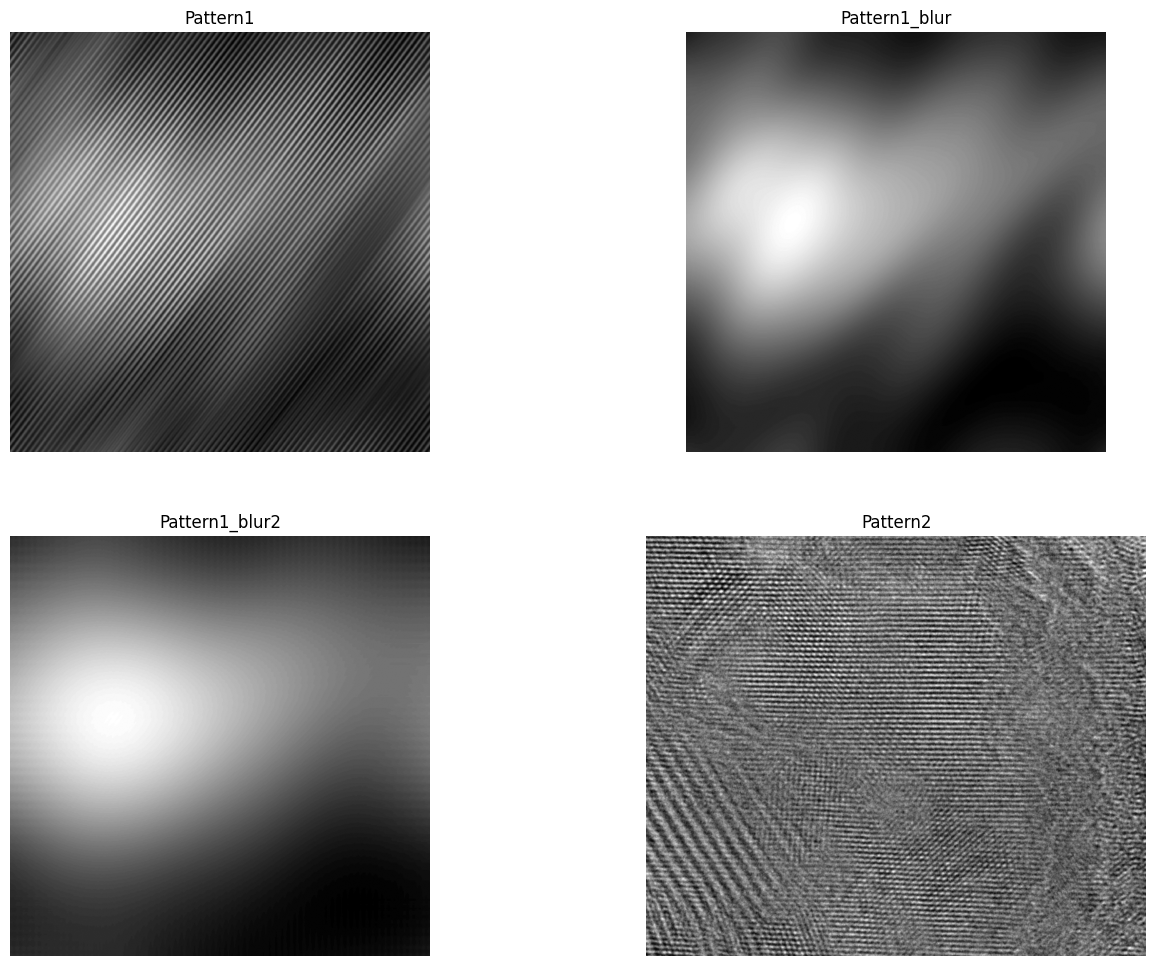

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
for i, (key, img) in enumerate(imgs.items()):
    ax[i // 2, i % 2].imshow(img["img"], cmap='gray')
    ax[i // 2, i % 2].set_title(key)
    ax[i // 2, i % 2].axis('off')


## A)

In [36]:
def filtro_passa_baixa(img, sigma):
    """Aplica um filtro passa-baixa na imagem usando a transformada de Fourier"""
    # Aplicar a Transformada de Fourier
    dft = np.fft.fft2(img)

    # Calculando valores para aplicar no filtro passa baixa
    nx = dft.shape[1]
    ny = dft.shape[0]

    cxrange = np.concatenate(
        (
            np.arange(0, nx // 2 + 1),
            np.arange(-nx // 2 + 1, 0)
        )
    )
    cyrange = np.concatenate(
        (
            np.arange(0, ny // 2 + 1),
            np.arange(-ny // 2 + 1, 0)
        )
    )
    cx, cy = np.meshgrid(cxrange, cyrange)

    fxrange = cxrange * 2 * (np.pi / nx)
    fyrange = cyrange * 2 * (np.pi / ny)

    fx, fy = np.meshgrid(fxrange, fyrange)
    return np.exp(-(fx**2 + fy**2) / (2 * (sigma**2)))

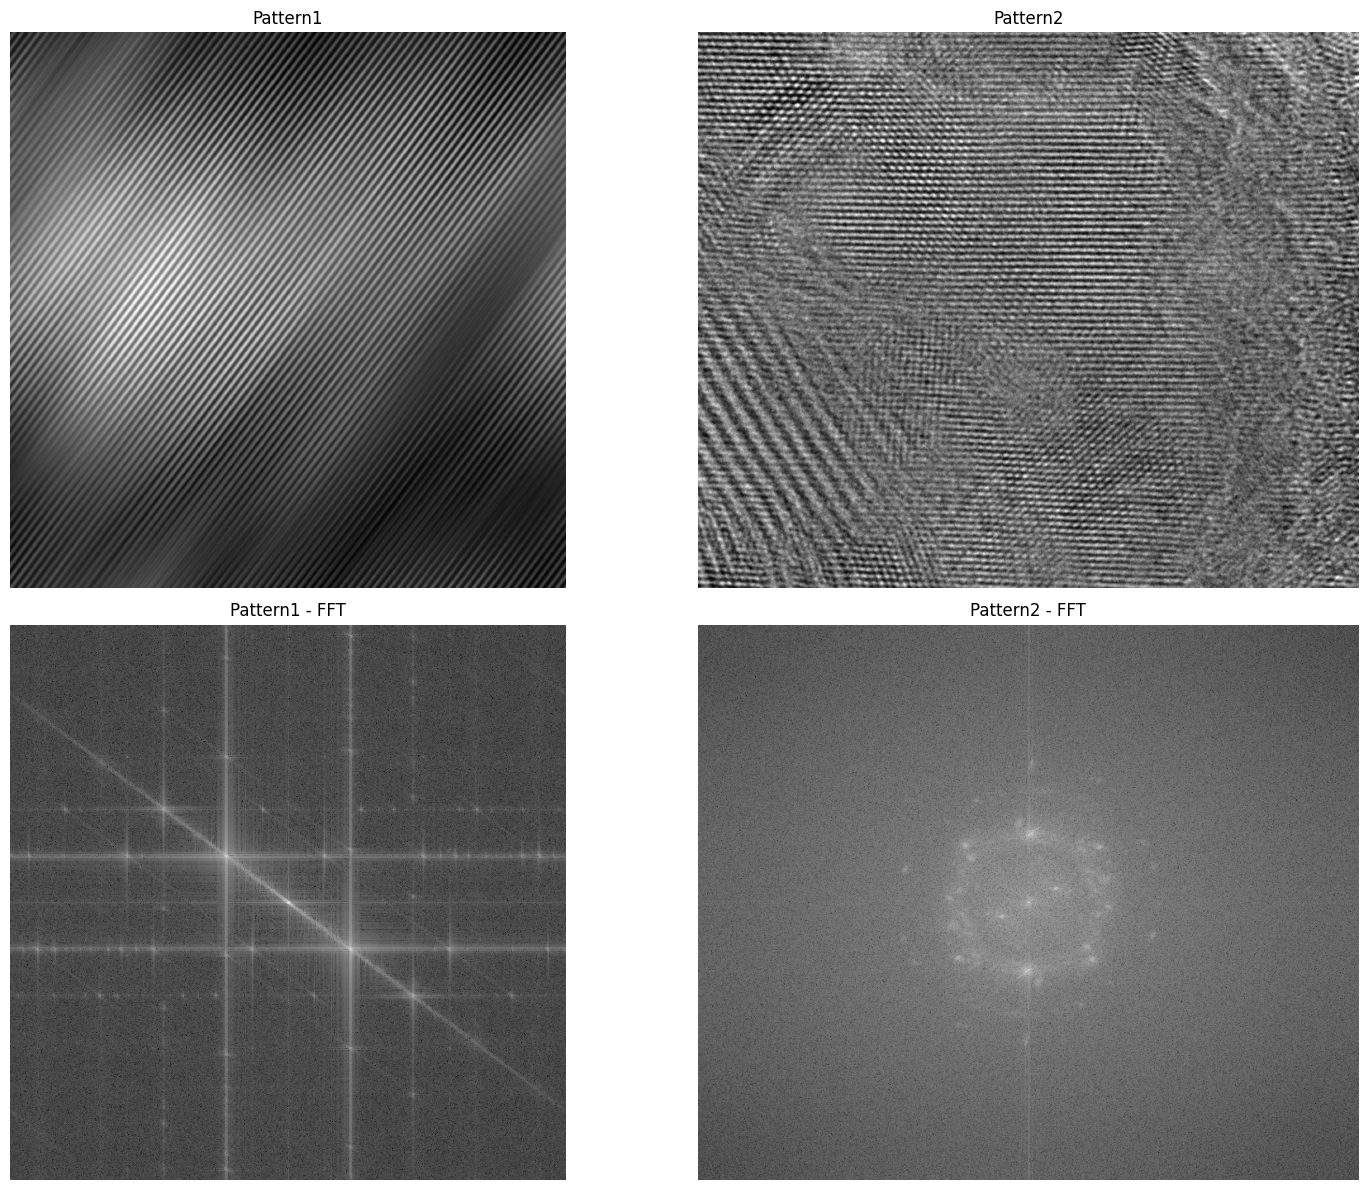

In [ ]:
lista_imgs = [
    "Pattern1",
    "Pattern2",
]
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
for i, key in enumerate(lista_imgs):
    ax[0, i].imshow(imgs[key]["img"], cmap='gray')
    ax[1, i].imshow(imgs[key]["img_fft"], cmap='gray')
    ax[0, i].set_title(key)
    ax[1, i].set_title(key + " - FFT")

    ax[0, i].axis('off')
    ax[1, i].axis('off')
fig.tight_layout()
fig.savefig(path_assets / "atv03_q01-01.png", dpi=400)

## B)